In [13]:
!pip install tensorflow matplotlib pandas scikit-learn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [14]:
# Import libraries
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [15]:
base_dir = "/home/dream/Desktop/research"

train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
val_df   = pd.read_csv(os.path.join(base_dir, "val.csv"))

print("Train CSV columns:", train_df.columns)
print("Validation CSV columns:", val_df.columns)


Train CSV columns: Index(['image:FILE', 'category'], dtype='object')
Validation CSV columns: Index(['image:FILE', 'category'], dtype='object')


In [16]:
train_df

,image:FILE,category
0,train/cat/Sphynx_159_jpg.rf.022528b23ac690c34a...,0
1,train/cat/Persian_139_jpg.rf.0e67f7e0a76dc49d0...,0
2,train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae...,0
3,train/cat/Bombay_140_jpg.rf.15757f698af74453f3...,0
4,train/cat/Persian_128_jpg.rf.16da80c477d1ca2bc...,0
...,...,...
270,train/dog/scottish_terrier_128_jpg.rf.cb2c8f24...,1
271,train/dog/samoyed_149_jpg.rf.c6bf305eaa640bc12...,1
272,train/dog/english_setter_172_jpg.rf.cb3f08fd8d...,1
273,train/dog/shiba_inu_135_jpg.rf.ca95dbdfbdf5b08...,1


In [17]:
img_size = (180,180)
batch_size = 2

# Normalization
train_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_datagen   = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Generator তৈরি
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image:FILE",
    y_col="category",
    target_size=img_size,
    class_mode="raw",  # binary label
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image:FILE",
    y_col="category",
    target_size=img_size,
    class_mode="raw",
    batch_size=batch_size,
    shuffle=False
)


Found 275 validated image filenames.
Found 70 validated image filenames.


In [18]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(180,180,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/home/dream/.local/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(train_gen, validation_data=val_gen, epochs=10)


Epoch 1/10


/home/dream/.local/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.6400 - loss: 0.7107 - val_accuracy: 0.6571 - val_loss: 0.9363
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.6509 - loss: 0.7077 - val_accuracy: 0.6571 - val_loss: 0.6259
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.6545 - loss: 0.6284 - val_accuracy: 0.6571 - val_loss: 0.6249
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.6727 - loss: 0.5925 - val_accuracy: 0.6571 - val_loss: 0.6729
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.7382 - loss: 0.5036 - val_accuracy: 0.4857 - val_loss: 0.6988
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.8618 - loss: 0.3217 - val_accuracy: 0.6429 - val_loss: 1.2028
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9091 - loss: 0.2086 - val_accuracy: 0.6571 - val_loss: 1.2995
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9491 - loss: 0.1270 - val

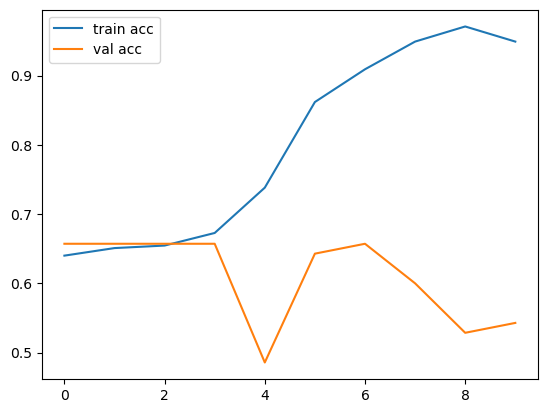

In [20]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()


In [21]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, 0)  # batch dimension

    prediction = model.predict(img_array)[0][0]
    if prediction > 0.5:
        print(f"{img_path} -> 🐶 Dog")
    else:
        print(f"{img_path} -> 🐱 Cat")


In [22]:
predict_image("/home/dream/Desktop/dog_test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
/home/dream/Desktop/dog_test.jpg -> 🐱 Cat
